In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
df = pd.read_csv('/content/bengaluru_house_prices.csv')

df.head()
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


In [3]:
def convert_sqft(x):
    x = str(x).strip()

    if '-' in x:
        a, b = x.split('-')
        return (float(a) + float(b)) / 2

    try:
        return float(x)
    except:
        return np.nan

In [4]:
df['total_sqft'] = df['total_sqft'].apply(convert_sqft)

In [5]:
df['bhk'] = df['size'].str.extract(r'(\d+)').astype(float)

In [6]:
df['ready_to_move'] = (
    df['availability']
    .str.lower()
    .eq('ready to move')
    .astype(int)
)

In [7]:
availability_date = pd.to_datetime(
    df['availability'].where(df['ready_to_move'] == 0),
    format='%y-%b',
    errors='coerce'
)

df['availability_year'] = availability_date.dt.year
df['availability_month'] = availability_date.dt.month

In [8]:
df = df.drop(
    columns=['society', 'size', 'availability']
)

In [9]:
df = df.dropna(
    subset=['location', 'total_sqft', 'bhk']
)

In [10]:
df['sqft_per_bhk'] = df['total_sqft'] / df['bhk']

df = df[df['sqft_per_bhk'] >= 300]

df = df[df['total_sqft'] <= 30000]

df = df[
    (df['bath'].isna()) |
    (df['bath'] <= df['bhk'] + 2)
]

df = df.drop(columns=['sqft_per_bhk'])

In [11]:
features = [
    'area_type',
    'location',
    'total_sqft',
    'bhk',
    'bath',
    'balcony',
    'ready_to_move',
    'availability_year',
    'availability_month'
]

X = df[features]
y = df['price']

In [12]:
y = np.log1p(y)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [16]:
categorical_features = [
    'area_type',
    'location'
]

numerical_features = [
    'total_sqft',
    'bhk',
    'bath',
    'balcony',
    'ready_to_move',
    'availability_year',
    'availability_month'
]

In [17]:
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [18]:
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

In [19]:
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

In [20]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [21]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(9999, 1137)
(2500, 1137)


In [22]:
model = Sequential([
    Dense(128, activation='relu',
          input_shape=(X_train_processed.shape[1],)),

    Dropout(0.10),

    Dense(64, activation='relu'),

    Dropout(0.10),

    Dense(32, activation='relu'),

    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       145,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 156,033 (609.50 KB)

 Trainable params: 156,033 (609.50 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

In [26]:
history = model.fit(
    X_train_processed,
    y_train,
    validation_split=0.20,
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 1.8950 - mae: 0.8595 - val_loss: 0.1520 - val_mae: 0.2848
Epoch 2/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2380 - mae: 0.3667 - val_loss: 0.1264 - val_mae: 0.2630
Epoch 3/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1952 - mae: 0.3371 - val_loss: 0.1536 - val_mae: 0.2858
Epoch 4/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1707 - mae: 0.3209 - val_loss: 0.1014 - val_mae: 0.2285
Epoch 5/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1544 - mae: 0.3021 - val_loss: 0.1019 - val_mae: 0.2344
Epoch 6/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1488 - mae: 0.2963 - val_loss: 0.0982 - val_mae: 0.2276
Epoch 7/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1415 - mae: 0.2856 - val_loss: 0.0900 - val_mae: 0.2153
Epoch 8/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1222 - mae: 0.2694 - val_loss: 0.0901 - val_mae: 0.2179
Epoch 9/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/

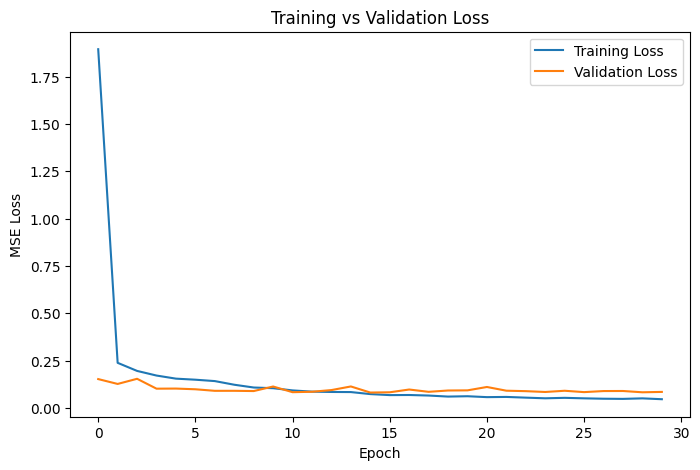

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

In [28]:
y_pred_log = model.predict(X_test_processed)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [29]:
y_pred = np.expm1(y_pred_log.flatten())
y_test_original = np.expm1(y_test)

In [30]:
mae = mean_absolute_error(
    y_test_original,
    y_pred
)

print("MAE:", mae)

MAE: 29.131287067337038


In [31]:
mse = mean_squared_error(
    y_test_original,
    y_pred
)

print("MSE:", mse)

MSE: 7629.703931058383


In [32]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 87.34817646097933


In [33]:
r2 = r2_score(
    y_test_original,
    y_pred
)

print("R²:", r2)

R²: 0.6537448248570485


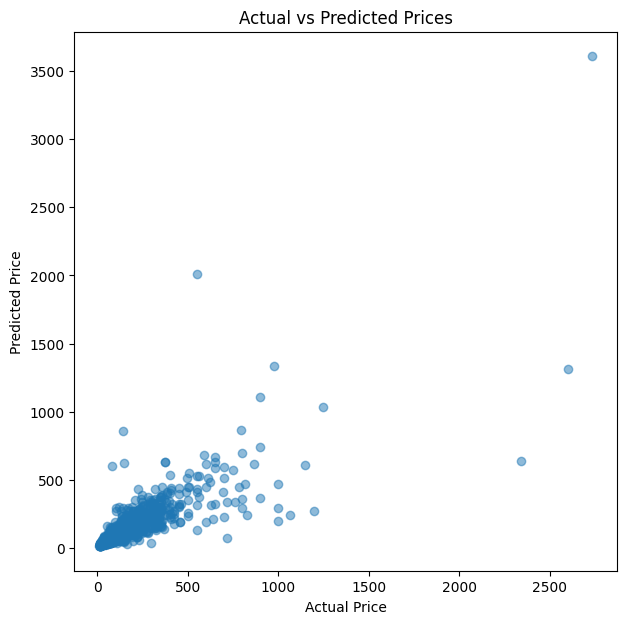

In [34]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test_original,
    y_pred,
    alpha=0.5
)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')

plt.show()

In [36]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_processed.shape[1],)),
    Dropout(0.10),
    Dense(64, activation='relu'),
    Dropout(0.10),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
history = model.fit(
    X_train_processed,
    y_train,
    validation_split=0.20,
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 1.9878 - mae: 0.8691 - val_loss: 0.1608 - val_mae: 0.2941
Epoch 2/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2347 - mae: 0.3591 - val_loss: 0.1209 - val_mae: 0.2581
Epoch 3/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1836 - mae: 0.3262 - val_loss: 0.1041 - val_mae: 0.2395
Epoch 4/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1517 - mae: 0.3012 - val_loss: 0.1372 - val_mae: 0.2758
Epoch 5/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1421 - mae: 0.2915 - val_loss: 0.1082 - val_mae: 0.2463
Epoch 6/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1247 - mae: 0.2719 - val_loss: 0.0945 - val_mae: 0.2232
Epoch 7/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1123 - mae: 0.2575 - val_loss: 0.1041 - val_mae: 0.2394
Epoch 8/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1076 - mae: 0.2506 - val_loss: 0.0944 - val_mae: 0.2250
Epoch 9/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/